# 1. Feature selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [2]:
# 1) Project paths (repo-friendly)
PROJECT_ROOT = Path.cwd().parent
data = PROJECT_ROOT / "data"
output = PROJECT_ROOT / "output"
figures = PROJECT_ROOT / "figures"


In [3]:
# create folders if they don't exist
output.mkdir(parents=True, exist_ok=True)
figures.mkdir(parents=True, exist_ok=True)

In [5]:
# 2) Raw dataset file
raw_file = data / "Crime_Data_from_2020_to_Present.csv"
# 3) Safety check
if not raw_file.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at: {raw_file}\n"
        "Fix: put the CSV in the repo folder /data/ with this exact name:\n"
        "data/Crime_Data_from_2020_to_Present.csv"
    )

In [6]:
#data loading
df = pd.read_csv(raw_file, low_memory=False)

In [7]:
#finding a column by trying a few common names 
def find_col(df, candidates):
    #making a lookup that ignores case and spaces
    norm = {c.replace(" ","").strip().upper(): c for c in df.columns}
    for cand in candidates:
        key = cand.replace(" ","").strip().upper()
        if key in norm:
            return norm[key]
    return None

In [8]:
#columns i need to keep for my hypotheses+preprocessing
need_map={
    "DR_NO":["DR_NO", "DR NO", "DR NUMBER"],
    "DATE_OCC":["DATE OCC", "DATE OCCURRED", "DATE_OCC"],
    "DATE_RPTD":["DATE RPTD", "DATE REPTD", "DATE REPORTED", "DATE_RPTD"],
    "TIME_OCC":["TIME OCC", "TIME OCCURRED", "TIME_OCC"],
    "CRM_CD":["Crm Cd", "CRM CD", "CRIME CODE"],
    "CRM_CD_DESC":["Crm Cd Desc", "CRM CD DESC", "CRIME CODE DESCRIPTION"],
    "WEAPON_DESC":["Weapon Desc", "WEAPON DESC", "WEAPON DESCRIPTION"],
    "VICT_AGE":["Vict Age", "VICT AGE", "VICT_AGE"],
    "PREMIS_DESC": ["Premis Desc", "PREMIS DESC", "PREMISE DESCRIPTION"]}

In [9]:
#resolve actual column names in your file
keep_cols = {}
missing_keys = []
for key, cands in need_map.items():
    found = find_col(df, cands)
    if found is not None:
        keep_cols[key] = found
    else:
        missing_keys.append((key, cands))

print("Actual columns:")
for k, v in keep_cols.items():
    print(f"  {k} -> {v}")

if missing_keys:
    print("\nWARNING:these important fields were not found. Check spelling or case in the CSV")
    for key, cands in missing_keys:
        print(f"  {key}: tried {cands}")


Actual columns:
  DR_NO -> DR_NO
  DATE_OCC -> DATE OCC
  DATE_RPTD -> Date Rptd
  TIME_OCC -> TIME OCC
  CRM_CD -> Crm Cd
  CRM_CD_DESC -> Crm Cd Desc
  WEAPON_DESC -> Weapon Desc
  VICT_AGE -> Vict Age
  PREMIS_DESC -> Premis Desc


In [10]:
#making a small working copy with just the needed columns and original df stays intact
needed_actual_names = list(keep_cols.values())
df_small = df[needed_actual_names].copy()
print("\nfinal kept columns:", needed_actual_names)


final kept columns: ['DR_NO', 'DATE OCC', 'Date Rptd', 'TIME OCC', 'Crm Cd', 'Crm Cd Desc', 'Weapon Desc', 'Vict Age', 'Premis Desc']


          Category  Count
0     Kept Columns      9
1  Dropped Columns     19
2    Total Columns     28


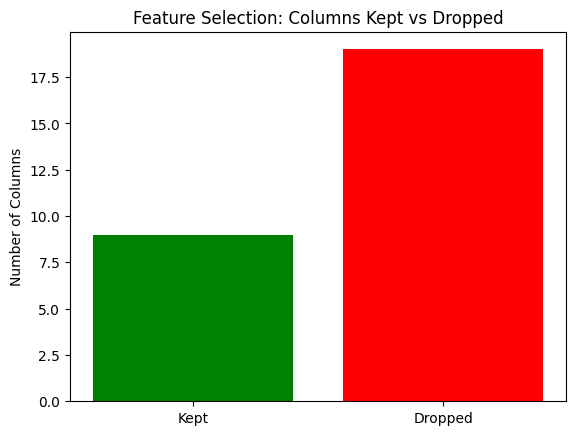

In [11]:
total_cols = df.shape[1]
kept_cols = len(needed_actual_names)
dropped_cols = total_cols - kept_cols

#a summary table
summary = pd.DataFrame({
    "Category": ["Kept Columns", "Dropped Columns", "Total Columns"],
    "Count": [kept_cols, dropped_cols, total_cols]
})
print(summary)

#bar chart
plt.bar(["Kept", "Dropped"], [kept_cols, dropped_cols], color=["green", "red"])
plt.title("Feature Selection: Columns Kept vs Dropped")
plt.ylabel("Number of Columns")
plt.savefig(figures/"Feature Selection_Columns Kept vs Dropped.png", dpi=300, bbox_inches="tight")
plt.show()


# 2 Standardization of column names

In [12]:
#renaming columns to snake_case and upper case
df_small.columns = [col.replace(" ", "_").upper() for col in df_small.columns]
#final kept columns
print("\nFinal kept columns (snake_case, upper case):", df_small.columns.tolist())
print("original shape:", df.shape, "   Small working shape:", df_small.shape)


Final kept columns (snake_case, upper case): ['DR_NO', 'DATE_OCC', 'DATE_RPTD', 'TIME_OCC', 'CRM_CD', 'CRM_CD_DESC', 'WEAPON_DESC', 'VICT_AGE', 'PREMIS_DESC']
original shape: (1004991, 28)    Small working shape: (1004991, 9)


In [13]:
#saving the smaller working file for processing later
df_small.to_csv(output/"crime_small_for_hypotheses.csv", index=False)
print("saved")

saved


# 3 Missing value handling

In [14]:
#missing values count per column
print("Missing values before handling:")
missing_before = df_small.isna().sum()
print(df_small.isna().sum())


Missing values before handling:
DR_NO               0
DATE_OCC            0
DATE_RPTD           0
TIME_OCC            0
CRM_CD              0
CRM_CD_DESC         0
WEAPON_DESC    677744
VICT_AGE            0
PREMIS_DESC       588
dtype: int64


In [15]:
for col in df_small.columns:
    if pd.api.types.is_numeric_dtype(df_small[col]):
        df_small[col] = df_small[col].where(df_small[col].notna(), None)
    else:
        df_small[col] = df_small[col].fillna("UNKNOWN")

print("\nmissing values after handling:")
print(df_small.isna().sum())


missing values after handling:
DR_NO          0
DATE_OCC       0
DATE_RPTD      0
TIME_OCC       0
CRM_CD         0
CRM_CD_DESC    0
WEAPON_DESC    0
VICT_AGE       0
PREMIS_DESC    0
dtype: int64


In [ ]:
# cleaned version
#df_small.to_csv("crime_small_missing_handled.csv", index=False)
#print("missing value handled file saved as 'crime_small_missing_handled.csv'")


# 4 Formatting the date

In [16]:
df_small['DATE_OCC'] = pd.to_datetime(df_small['DATE_OCC'], errors='coerce')
df_small['DATE_OCC'] = df_small['DATE_OCC'].dt.strftime('%m-%d-%Y')

df_small['DATE_RPTD'] = pd.to_datetime(df_small['DATE_RPTD'], errors='coerce')
df_small['DATE_RPTD'] = df_small['DATE_RPTD'].dt.strftime('%m-%d-%Y')

print(df_small[['DATE_OCC', 'DATE_RPTD']].head())


C:\Users\rupa1\AppData\Local\Temp\ipykernel_21268\3729575635.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_small['DATE_OCC'] = pd.to_datetime(df_small['DATE_OCC'], errors='coerce')
C:\Users\rupa1\AppData\Local\Temp\ipykernel_21268\3729575635.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_small['DATE_RPTD'] = pd.to_datetime(df_small['DATE_RPTD'], errors='coerce')


     DATE_OCC   DATE_RPTD
0  11-07-2020  04-11-2021
1  10-18-2020  10-21-2020
2  10-30-2020  12-10-2024
3  12-24-2020  12-24-2020
4  09-29-2020  10-03-2020


# 5 feature making

In [17]:
df_small['DATE_OCC'] = pd.to_datetime(df_small['DATE_OCC'], errors='coerce')
df_small['YEAR'] = df_small['DATE_OCC'].dt.year
df_small['MONTH'] = df_small['DATE_OCC'].dt.month
df_small['WEEKDAY'] = df_small['DATE_OCC'].dt.day_name().str.upper()
df_small['DATE_OCC'] = df_small['DATE_OCC'].dt.strftime('%m-%d-%Y')

print(df_small[['DATE_OCC', 'YEAR', 'MONTH', 'WEEKDAY']].head())

     DATE_OCC  YEAR  MONTH   WEEKDAY
0  11-07-2020  2020     11  SATURDAY
1  10-18-2020  2020     10    SUNDAY
2  10-30-2020  2020     10    FRIDAY
3  12-24-2020  2020     12  THURSDAY
4  09-29-2020  2020      9   TUESDAY


In [18]:
df_small

,DR_NO,DATE_OCC,DATE_RPTD,TIME_OCC,CRM_CD,CRM_CD_DESC,WEAPON_DESC,VICT_AGE,PREMIS_DESC,YEAR,MONTH,WEEKDAY
0,211507896,11-07-2020,04-11-2021,845,354,THEFT OF IDENTITY,UNKNOWN,31,SINGLE FAMILY DWELLING,2020,11,SATURDAY
1,201516622,10-18-2020,10-21-2020,1845,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",KNIFE WITH BLADE 6INCHES OR LESS,32,SIDEWALK,2020,10,SUNDAY
2,240913563,10-30-2020,12-10-2024,1240,354,THEFT OF IDENTITY,UNKNOWN,30,SINGLE FAMILY DWELLING,2020,10,FRIDAY
3,210704711,12-24-2020,12-24-2020,1310,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,UNKNOWN,47,STREET,2020,12,THURSDAY
4,201418201,09-29-2020,10-03-2020,1830,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),UNKNOWN,63,ALLEY,2020,9,TUESDAY
...,...,...,...,...,...,...,...,...,...,...,...,...
1004986,252104112,02-02-2025,02-02-2025,130,946,OTHER MISCELLANEOUS CRIME,UNKNOWN,35,STREET,2025,2,SUNDAY
1004987,250404100,02-18-2025,02-18-2025,1000,237,CHILD NEGLECT (SEE 300 W.I.C.),UNKNOWN,11,SINGLE FAMILY DWELLING,2025,2,TUESDAY
1004988,251304095,01-30-2025,01-31-2025,1554,850,INDECENT EXPOSURE,UNKNOWN,16,STREET,2025,1,THURSDAY
1004989,251704066,01-17-2025,01-17-2025,1600,624,BATTERY - SIMPLE ASSAULT,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",17,HIGH SCHOOL,2025,1,FRIDAY


# 6 TIME_OCC digit formatting

In [19]:
df_small['TIME_OCC'] = df_small['TIME_OCC'].astype(str).str.zfill(4)

print("\nFormatted TIME_OCC sample values:")
print(df_small['TIME_OCC'].head())


Formatted TIME_OCC sample values:
0    0845
1    1845
2    1240
3    1310
4    1830
Name: TIME_OCC, dtype: object


# 7 Data Binning

In [20]:
#time binning:creating DAYPART from TIME_OCC
df_small['HOUR'] = df_small['TIME_OCC'].str[:2].astype(int)
def get_daypart(h):
    if 5 <= h <= 11:
        return "MORNING"
    elif 12 <= h <= 16:
        return "AFTERNOON"
    elif 17 <= h <= 20:
        return "EVENING"
    else:
        return "NIGHT"

df_small['DAYPART'] = df_small['HOUR'].apply(get_daypart)

print("\ndaypart distribution:")
print(df_small['DAYPART'].value_counts())


daypart distribution:
DAYPART
NIGHT        278566
AFTERNOON    268501
EVENING      230716
MORNING      227208
Name: count, dtype: int64


In [21]:
#age binning:creating AGE_GROUP from VICT_AGE
age_bins = [-1, 17, 29, 44, 64, 150]
age_labels = ['UNDER_18', 'YOUNG_ADULT', 'MIDDLE_AGED_ADULTS', 'OLDER_ADULTS', 'SENIORS']

df_small['AGE_GROUP'] = pd.cut(df_small['VICT_AGE'].astype(float), bins=age_bins, labels=age_labels)

print("\nage group distribution:")
print(df_small['AGE_GROUP'].value_counts())


age group distribution:
AGE_GROUP
UNDER_18              294820
MIDDLE_AGED_ADULTS    266481
YOUNG_ADULT           195843
OLDER_ADULTS          192197
SENIORS                55513
Name: count, dtype: int64


In [22]:
df_small

,DR_NO,DATE_OCC,DATE_RPTD,TIME_OCC,CRM_CD,CRM_CD_DESC,WEAPON_DESC,VICT_AGE,PREMIS_DESC,YEAR,MONTH,WEEKDAY,HOUR,DAYPART,AGE_GROUP
0,211507896,11-07-2020,04-11-2021,0845,354,THEFT OF IDENTITY,UNKNOWN,31,SINGLE FAMILY DWELLING,2020,11,SATURDAY,8,MORNING,MIDDLE_AGED_ADULTS
1,201516622,10-18-2020,10-21-2020,1845,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",KNIFE WITH BLADE 6INCHES OR LESS,32,SIDEWALK,2020,10,SUNDAY,18,EVENING,MIDDLE_AGED_ADULTS
2,240913563,10-30-2020,12-10-2024,1240,354,THEFT OF IDENTITY,UNKNOWN,30,SINGLE FAMILY DWELLING,2020,10,FRIDAY,12,AFTERNOON,MIDDLE_AGED_ADULTS
3,210704711,12-24-2020,12-24-2020,1310,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,UNKNOWN,47,STREET,2020,12,THURSDAY,13,AFTERNOON,OLDER_ADULTS
4,201418201,09-29-2020,10-03-2020,1830,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),UNKNOWN,63,ALLEY,2020,9,TUESDAY,18,EVENING,OLDER_ADULTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004986,252104112,02-02-2025,02-02-2025,0130,946,OTHER MISCELLANEOUS CRIME,UNKNOWN,35,STREET,2025,2,SUNDAY,1,NIGHT,MIDDLE_AGED_ADULTS
1004987,250404100,02-18-2025,02-18-2025,1000,237,CHILD NEGLECT (SEE 300 W.I.C.),UNKNOWN,11,SINGLE FAMILY DWELLING,2025,2,TUESDAY,10,MORNING,UNDER_18
1004988,251304095,01-30-2025,01-31-2025,1554,850,INDECENT EXPOSURE,UNKNOWN,16,STREET,2025,1,THURSDAY,15,AFTERNOON,UNDER_18
1004989,251704066,01-17-2025,01-17-2025,1600,624,BATTERY - SIMPLE ASSAULT,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",17,HIGH SCHOOL,2025,1,FRIDAY,16,AFTERNOON,UNDER_18


C:\Users\rupa1\AppData\Local\Temp\ipykernel_21268\935677698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DAYPART', data=df_small, order=df_small['DAYPART'].value_counts().index, palette="Set2")


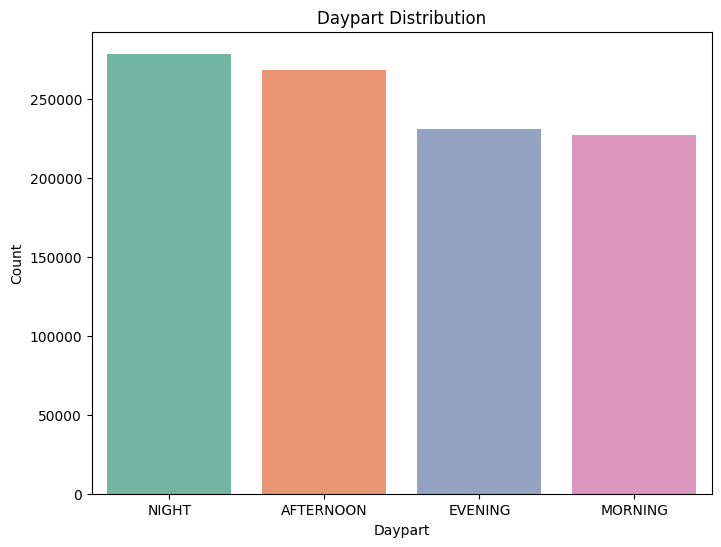

C:\Users\rupa1\AppData\Local\Temp\ipykernel_21268\935677698.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AGE_GROUP', data=df_small, order=df_small['AGE_GROUP'].value_counts().index, palette="Set3")


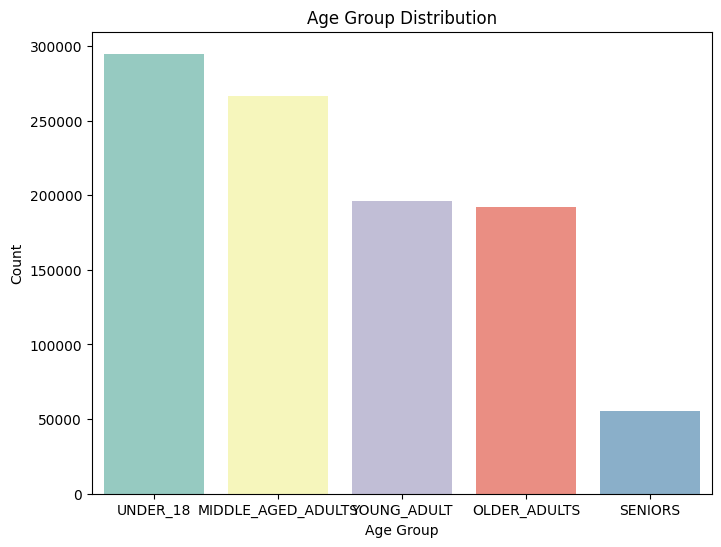

In [23]:

#plotting daypart distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='DAYPART', data=df_small, order=df_small['DAYPART'].value_counts().index, palette="Set2")
plt.title("Daypart Distribution")
plt.xlabel("Daypart")
plt.ylabel("Count")
plt.savefig(figures/"Daypart Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#plotting age group distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='AGE_GROUP', data=df_small, order=df_small['AGE_GROUP'].value_counts().index, palette="Set3")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.savefig(figures/"Age Group Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# crime description grouping

In [24]:
#number of unique crime descriptions
unique_count = df_small['CRM_CD_DESC'].nunique()
print(f"\nNumber of unique CRM_CD_DESC values: {unique_count}")

print("\nUnique CRM_CD_DESC values:")
print(df_small['CRM_CD_DESC'].unique())


Number of unique CRM_CD_DESC values: 140

Unique CRM_CD_DESC values:
['THEFT OF IDENTITY' 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT'
 'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)'
 'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)'
 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)'
 'VEHICLE - STOLEN' 'BURGLARY' 'BURGLARY FROM VEHICLE'
 'THEFT PLAIN - PETTY ($950 & UNDER)' 'INTIMATE PARTNER - SIMPLE ASSAULT'
 'BATTERY - SIMPLE ASSAULT' 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)'
 'VEHICLE - ATTEMPT STOLEN'
 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)' 'ROBBERY'
 'FIREARMS RESTRAINING ORDER (FIREARMS RO)' 'BIKE - STOLEN'
 'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)'
 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT'
 'CRIMINAL THREATS - NO WEAPON DISPLAYED'
 'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD'
 'BATTERY WITH SEXUAL CONTACT' 'LETTERS, LEWD  -  TELEPHONE CALLS, LEWD'
 'VIOLATION OF COURT ORDER' 'ARSON' 'VIOLATION OF RESTRAINING ORDER'
 'TH

In [25]:
# binning crm_cd_desc into violent vs white_collar (else other)
_desc = df_small['CRM_CD_DESC'].astype(str).str.upper().str.strip()

violent_terms = [
    'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'ROBBERY', 'BATTERY - SIMPLE ASSAULT',
    'THEFT PLAIN - ATTEMPT', 'BATTERY WITH SEXUAL CONTACT', 'BATTERY POLICE (SIMPLE)', 'RAPE, ATTEMPTED', 
    'RAPE, FORCIBLE', 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT', 'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT',
    'KIDNAPPING', 'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER', 'MANSLAUGHTER, NEGLIGENT', 'STABBING', 
    'HOMICIDE', 'MURDER', 'SEXUAL ASSAULT', 'SEXUAL PENETRATION W/FOREIGN OBJECT', 'PICKPOCKET', 'CHILD STEALING',
    'PIMPING', 'HUMAN TRAFFICKING - COMMERCIAL SEX ACTS', 'SEXUAL PENETRATION W/FOREIGN OBJECT', 
    'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)', 'LEWD/LASCIVIOUS ACTS WITH CHILD', 'SEX OFFENDER REGISTRANT OUT OF COMPLIANCE',
    'SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH', 'PEEPING TOM', 'STALKING', 'CRIMINAL HOMICIDE', 
    'SHOTS FIRED', 'SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT', 'ASSAULT WITH A DEADLY WEAPON',
    'THROWING OBJECT AT MOVING VEHICLE', 'SHOTS FIRED AT INHABITED DWELLING', 'SHOTS FIRED AT MOVING VEHICLE', 
    'BOMBING', 'DISCHARGE FIREARMS/SHOTS FIRED', 'MANSLAUGHTER', 'HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE',
    'AGGRAVATED ASSAULT', 'BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM', 'LYNCHING', 'LYNCHING - ATTEMPTED', 
    'TERRORIST THREATS', 'ASSAULT', 'ATTEMPTED MURDER', 'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)', 'ASSAULT'
]

white_collar_terms = [
    'THEFT OF IDENTITY', 'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)',
    'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)', 'VEHICLE - STOLEN', 'BURGLARY',
    'BURGLARY FROM VEHICLE', 'THEFT PLAIN - PETTY ($950 & UNDER)', 'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)',
    'DOCUMENT FORGERY / STOLEN FELONY', 'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD',
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)', 'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)', 
    'BUNCO, ATTEMPT', 'BUNCO, GRAND THEFT', 'BUNCO, PETTY THEFT', 'DISHONEST EMPLOYEE - PETTY THEFT', 
    'DISHONEST EMPLOYEE - GRAND THEFT', 'FALSE POLICE REPORT', 'DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER',
    'CREDIT CARDS, FRAUD USE ($950 & UNDER)', 'CREDIT CARDS, FRAUD USE ($950.01 & OVER)', 
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01', 'COUNTERFEIT', 'DOCUMENT WORTHLESS ($200.01 & OVER)', 
    'DOCUMENT WORTHLESS ($200 & UNDER)', 'CREDIT CARDS, FRAUD USE ($950 & UNDER)', 'THEFT, COIN MACHINE - PETTY ($950 & UNDER)',
    'THEFT, COIN MACHINE - ATTEMPT', 'THEFT, COIN MACHINE - GRAND ($950.01 & OVER)', 'GRAND THEFT / INSURANCE FRAUD', 
    'THEFT, COIN MACHINE - GRAND ($950.01 & OVER)', 'THEFT FROM PERSON - ATTEMPT', 'BUNCO, ATTEMPT', 
    'TILL TAP - PETTY ($950 & UNDER)', 'TILL TAP - GRAND THEFT ($950.01 & OVER)', 'THEFT, COIN MACHINE - GRAND ($950.01 & OVER)', 
    'GRAND THEFT / AUTO REPAIR', 'GRAND THEFT / INSURANCE FRAUD', 'THEFT FROM MOTOR VEHICLE - ATTEMPT', 
    'GRAND THEFT / AUTO REPAIR'
]

def _contains_any(s, terms):
    return any(t in s for t in terms)
df_small['CRIME_CLASS'] = (
    _desc.apply(lambda s: 'VIOLENT' if _contains_any(s, violent_terms)
                else ('WHITE_COLLAR' if _contains_any(s, white_collar_terms)
                      else 'OTHER')))

print("\ncrime class distribution:")
print(df_small['CRIME_CLASS'].value_counts(dropna=False))


crime class distribution:
CRIME_CLASS
WHITE_COLLAR    525729
VIOLENT         262914
OTHER           216348
Name: count, dtype: int64


In [26]:
df_small

,DR_NO,DATE_OCC,DATE_RPTD,TIME_OCC,CRM_CD,CRM_CD_DESC,WEAPON_DESC,VICT_AGE,PREMIS_DESC,YEAR,MONTH,WEEKDAY,HOUR,DAYPART,AGE_GROUP,CRIME_CLASS
0,211507896,11-07-2020,04-11-2021,0845,354,THEFT OF IDENTITY,UNKNOWN,31,SINGLE FAMILY DWELLING,2020,11,SATURDAY,8,MORNING,MIDDLE_AGED_ADULTS,WHITE_COLLAR
1,201516622,10-18-2020,10-21-2020,1845,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",KNIFE WITH BLADE 6INCHES OR LESS,32,SIDEWALK,2020,10,SUNDAY,18,EVENING,MIDDLE_AGED_ADULTS,VIOLENT
2,240913563,10-30-2020,12-10-2024,1240,354,THEFT OF IDENTITY,UNKNOWN,30,SINGLE FAMILY DWELLING,2020,10,FRIDAY,12,AFTERNOON,MIDDLE_AGED_ADULTS,WHITE_COLLAR
3,210704711,12-24-2020,12-24-2020,1310,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,UNKNOWN,47,STREET,2020,12,THURSDAY,13,AFTERNOON,OLDER_ADULTS,WHITE_COLLAR
4,201418201,09-29-2020,10-03-2020,1830,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),UNKNOWN,63,ALLEY,2020,9,TUESDAY,18,EVENING,OLDER_ADULTS,WHITE_COLLAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004986,252104112,02-02-2025,02-02-2025,0130,946,OTHER MISCELLANEOUS CRIME,UNKNOWN,35,STREET,2025,2,SUNDAY,1,NIGHT,MIDDLE_AGED_ADULTS,OTHER
1004987,250404100,02-18-2025,02-18-2025,1000,237,CHILD NEGLECT (SEE 300 W.I.C.),UNKNOWN,11,SINGLE FAMILY DWELLING,2025,2,TUESDAY,10,MORNING,UNDER_18,OTHER
1004988,251304095,01-30-2025,01-31-2025,1554,850,INDECENT EXPOSURE,UNKNOWN,16,STREET,2025,1,THURSDAY,15,AFTERNOON,UNDER_18,OTHER
1004989,251704066,01-17-2025,01-17-2025,1600,624,BATTERY - SIMPLE ASSAULT,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",17,HIGH SCHOOL,2025,1,FRIDAY,16,AFTERNOON,UNDER_18,VIOLENT


In [27]:
df_small.to_csv(output/"dataset_after_preprocessing.csv", index=False)
print("file saved as 'dataset_after_preprocessing.csv'")

file saved as 'dataset_after_preprocessing.csv'


# hypotheses 1

In [28]:
#work copy
d = df_small.copy()

#keeping only violent and white-collar crimes
d = d[d['CRIME_CLASS'].isin(['VIOLENT','WHITE_COLLAR'])].copy()

In [29]:
#defining summer (june-august) using MONTH column
d['IS_SUMMER'] = d['MONTH'].isin([6,7,8])

#group by year,season(summer/non-summer),and crime class
summary = (
    d.groupby(['YEAR','CRIME_CLASS','IS_SUMMER'])
     .size()
     .reset_index(name='COUNT')
)

#summer=3 months,non-summer=9 months,
# normalize by number of months to compare fairly
summary['MONTHS'] = summary['IS_SUMMER'].map({True:3, False:9})
summary['AVG_PER_MONTH'] = summary['COUNT'] / summary['MONTHS']

print(summary.head())

   YEAR   CRIME_CLASS  IS_SUMMER  COUNT  MONTHS  AVG_PER_MONTH
0  2020       VIOLENT      False  42596       9    4732.888889
1  2020       VIOLENT       True  15356       3    5118.666667
2  2020  WHITE_COLLAR      False  71786       9    7976.222222
3  2020  WHITE_COLLAR       True  23708       3    7902.666667
4  2021       VIOLENT      False  43194       9    4799.333333


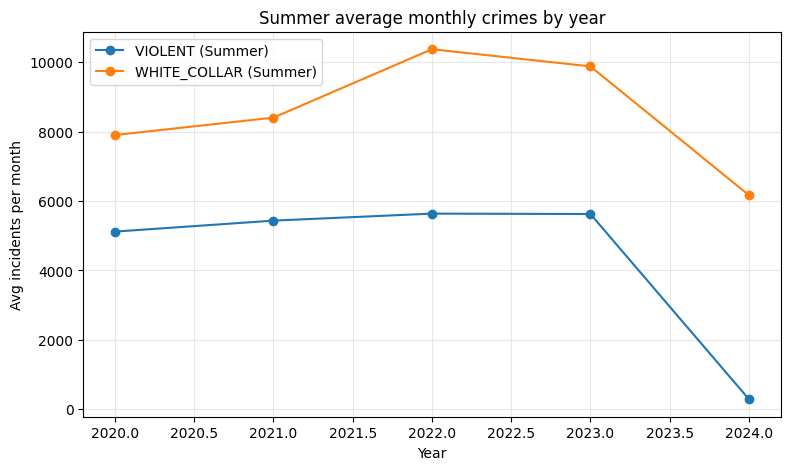

In [30]:
#plotting 1:summer trends by year
plt.figure(figsize=(9,5))
for c in ['VIOLENT','WHITE_COLLAR']:
    s = summary[(summary['CRIME_CLASS']==c) & (summary['IS_SUMMER']==True)]
    plt.plot(s['YEAR'], s['AVG_PER_MONTH'], marker='o', label=f"{c} (Summer)")

plt.title("Summer average monthly crimes by year")
plt.xlabel("Year")
plt.ylabel("Avg incidents per month")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(figures/"Summer average monthly crimes by year.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
#making a pivot so each row is (YEAR,CLASS) and columns are summer or non-summer
pivot=(summary
    .pivot_table(index=['YEAR','CRIME_CLASS'],
                 columns='IS_SUMMER',
                 values='AVG_PER_MONTH',
                 aggfunc='sum')
    .reset_index())
#rename columns:True->'SUMMER',False->'NON_SUMMER'
pivot = pivot.rename(columns={True:'SUMMER', False:'NON_SUMMER'}).sort_values(['CRIME_CLASS','YEAR'])
classes = ['VIOLENT','WHITE_COLLAR']

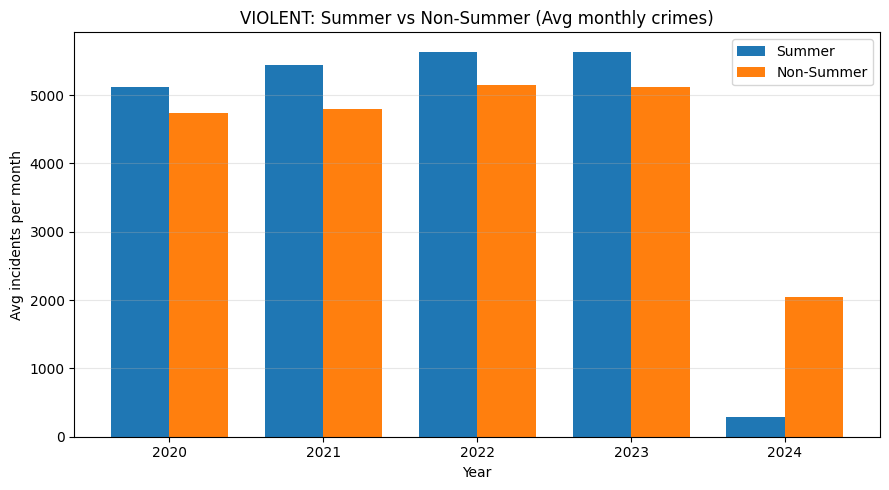

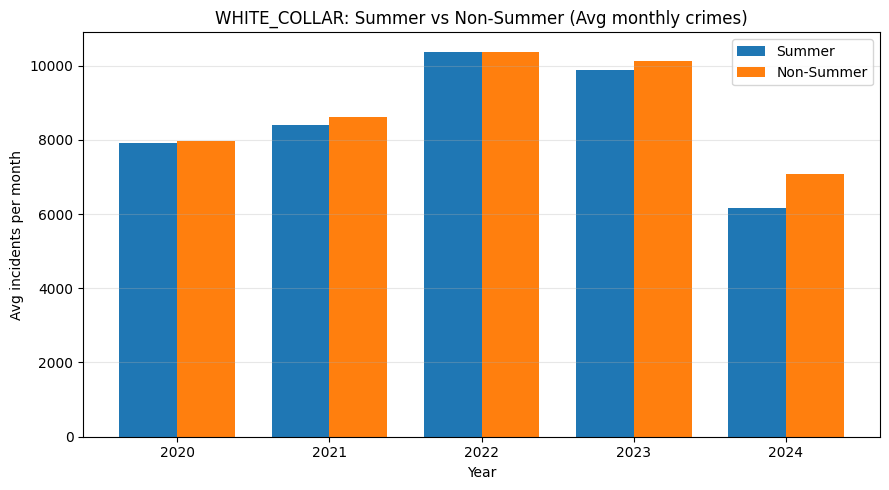

In [33]:
for c in classes:
    sub = pivot[pivot['CRIME_CLASS'] == c].copy().sort_values('YEAR')
    #either keeping only years where BOTH seasons exist
    strict = sub.dropna(subset=['SUMMER','NON_SUMMER']).copy()
    #or filling missing with 0 so arrays match (can be used if data is incomplete)
    safe = sub.fillna(0).copy()
    #choosing one-strict or safe
    use = strict if len(strict) >= 2 else safe  #my preference is strict, will fallback to safe if too few rows
    years = use['YEAR'].astype(int).tolist()
    summer_vals = use['SUMMER'].tolist()
    nonsummer_vals = use['NON_SUMMER'].tolist()

    x = range(len(years))
    width = 0.38

    plt.figure(figsize=(9,5))
    plt.bar([i - width/2 for i in x], summer_vals, width=width, label='Summer')
    plt.bar([i + width/2 for i in x], nonsummer_vals, width=width, label='Non-Summer')
    plt.title(f"{c}: Summer vs Non-Summer (Avg monthly crimes)")
    plt.xlabel("Year")
    plt.ylabel("Avg incidents per month")
    plt.xticks(x, years)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(figures/f"{c}_Summer vs Non-Summer_Avg monthly crimes.png", dpi=300, bbox_inches="tight")
    plt.show()

# Hypotheses 2

In [34]:
#data loading 
path = output/"dataset_after_preprocessing.csv"
df_small = pd.read_csv(path,low_memory=False)

In [ ]:
df_small

In [35]:
# Start from violent crimes only, keep rows with AGE_GROUP and DAYPART
v = df_small[df_small['CRIME_CLASS'] == 'VIOLENT'].dropna(subset=['AGE_GROUP','DAYPART']).copy()

# Define young vs other
v['IS_YOUNG'] = (v['AGE_GROUP'] == 'YOUNG_ADULT')
v['IS_EVE_NIGHT'] = v['DAYPART'].isin(['EVENING','NIGHT'])


Overall (violent): Young vs Other share by year (%):
 YEAR  YOUNG_PCT  OTHER_PCT
 2020       29.2       70.8
 2021       29.0       71.0
 2022       27.9       72.1
 2023       27.5       72.5
 2024       28.7       71.3
 2025        4.5       95.5


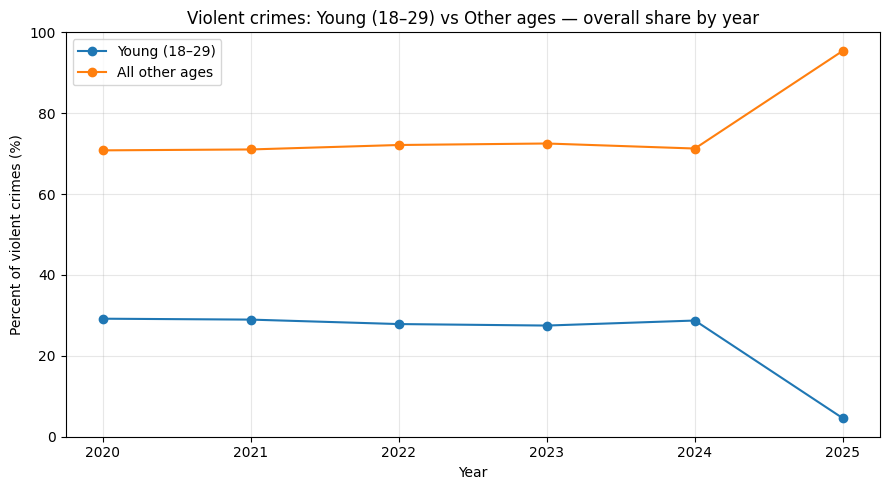

In [36]:
#(1) OVERALL: Young vs Other share by year 
overall = (
    v.groupby('YEAR')['IS_YOUNG']
     .mean()                               # mean(True/False) = share young
     .reset_index(name='YOUNG_SHARE')
     .sort_values('YEAR')
)
overall['OTHER_SHARE'] = 1 - overall['YOUNG_SHARE']

print("\nOverall (violent): Young vs Other share by year (%):")
print(overall.assign(YOUNG_PCT=(overall['YOUNG_SHARE']*100).round(1),
                     OTHER_PCT=(overall['OTHER_SHARE']*100).round(1))
             [['YEAR','YOUNG_PCT','OTHER_PCT']].to_string(index=False))

plt.figure(figsize=(9,5))
plt.plot(overall['YEAR'], overall['YOUNG_SHARE']*100, marker='o', label='Young (18–29)')
plt.plot(overall['YEAR'], overall['OTHER_SHARE']*100, marker='o', label='All other ages')
plt.title('Violent crimes: Young (18–29) vs Other ages — overall share by year')
plt.xlabel('Year'); plt.ylabel('Percent of violent crimes (%)')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); 
plt.savefig(figures/f"Violent crimes: Young (18–29) vs Other ages.png", dpi=300, bbox_inches="tight")
plt.show()


Evening+Night (violent): Young vs Other share by year (%):
 YEAR  YOUNG_PCT  OTHER_PCT
 2020       31.3       68.7
 2021       31.4       68.6
 2022       30.8       69.2
 2023       30.4       69.6
 2024       32.4       67.6


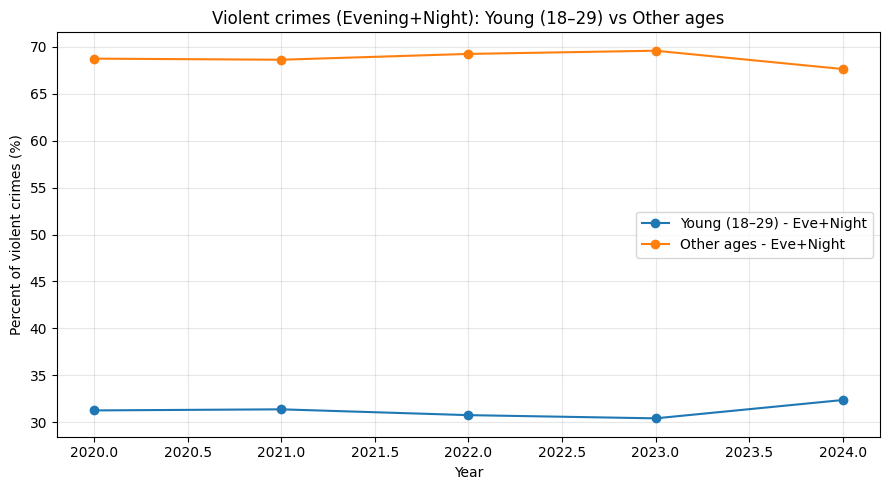

In [39]:
# (2) EVENING+NIGHT: Young vs Other share by year 
ve = v[v['IS_EVE_NIGHT']].copy()

en = (
    ve.groupby('YEAR')['IS_YOUNG']
      .mean()                              # among evening+night incidents: share young
      .reset_index(name='YOUNG_SHARE_EN')
      .sort_values('YEAR')
)
en['OTHER_SHARE_EN'] = 1 - en['YOUNG_SHARE_EN']

print("\nEvening+Night (violent): Young vs Other share by year (%):")
print(en.assign(YOUNG_PCT=(en['YOUNG_SHARE_EN']*100).round(1),
                OTHER_PCT=(en['OTHER_SHARE_EN']*100).round(1))
         [['YEAR','YOUNG_PCT','OTHER_PCT']].to_string(index=False))

plt.figure(figsize=(9,5))
plt.plot(en['YEAR'], en['YOUNG_SHARE_EN']*100, marker='o', label='Young (18–29) - Eve+Night')
plt.plot(en['YEAR'], en['OTHER_SHARE_EN']*100, marker='o', label='Other ages - Eve+Night')
plt.title('Violent crimes (Evening+Night): Young (18–29) vs Other ages')
plt.xlabel('Year'); plt.ylabel('Percent of violent crimes (%)')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); 
plt.savefig(figures/"Violent crimes (Evening+Night) Young (18–29) vs Other ages.png", dpi=300, bbox_inches="tight")
plt.show()

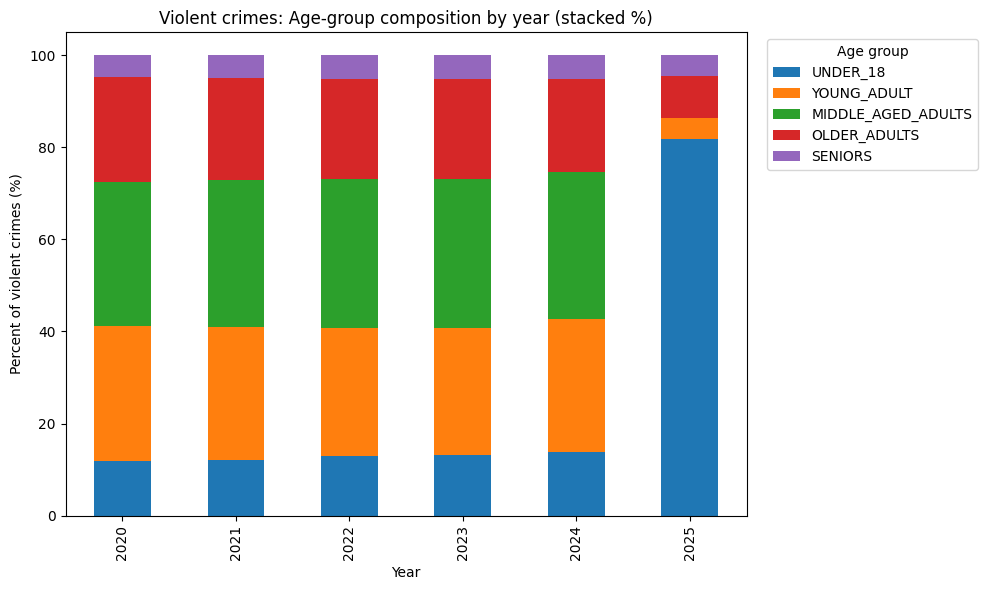

In [40]:
# Step 1: counts per (YEAR, AGE_GROUP)
dist_counts = (
    v.groupby(['YEAR', 'AGE_GROUP'])
      .size()
      .reset_index(name='COUNT')
)

# Step 2: total per YEAR
dist_counts['YEAR_TOTAL'] = dist_counts.groupby('YEAR')['COUNT'].transform('sum')

# Step 3: share within each YEAR
dist_counts['SHARE'] = dist_counts['COUNT'] / dist_counts['YEAR_TOTAL']

# Step 4: pivot to wide for stacked bar (%)
dist_p = (dist_counts
          .pivot(index='YEAR', columns='AGE_GROUP', values='SHARE')
          .fillna(0)
          .sort_index())

# optional: consistent column order if all exist
cols_order = ['UNDER_18','YOUNG_ADULT','MIDDLE_AGED_ADULTS','OLDER_ADULTS','SENIORS']
dist_p = dist_p.reindex(columns=[c for c in cols_order if c in dist_p.columns])

ax = (dist_p * 100).plot(kind='bar', stacked=True, figsize=(10,6))
ax.set_title('Violent crimes: Age-group composition by year (stacked %)')
ax.set_xlabel('Year'); ax.set_ylabel('Percent of violent crimes (%)')
ax.legend(title='Age group', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); 
plt.savefig(figures/f"Violent crimes_Age-group composition by year (stacked %).png", dpi=300, bbox_inches="tight")
plt.show()


# Hypothesis 3

In [41]:
# List all unique premises descriptions
premis_unique = df_small['PREMIS_DESC'].dropna().unique()
premis_unique_sorted = sorted(premis_unique)

print(f"Number of unique PREMIS_DESC values: {len(premis_unique_sorted)}\n")
for p in premis_unique_sorted:
    print(p)


Number of unique PREMIS_DESC values: 307

7TH AND METRO CENTER (NOT LINE SPECIFIC)
ABANDONED BUILDING ABANDONED HOUSE
ABATEMENT LOCATION
ABORTION CLINIC/ABORTION FACILITY*
AIRCRAFT
ALLEY
AMTRAK TRAIN
AMUSEMENT PARK*
APARTMENT/CONDO COMMON LAUNDRY ROOM
ARCADE,GAME ROOM/VIDEO GAMES (EXAMPLE CHUCKIE CHEESE)*
AUTO DEALERSHIP (CHEVY, FORD, BMW, MERCEDES, ETC.)
AUTO REPAIR SHOP
AUTO SALES LOT
AUTO SUPPLY STORE*
AUTOMATED TELLER MACHINE (ATM)
BALCONY*
BANK
BANK DROP BOX/MONEY DROP-OUTSIDE OF BANK*
BANKING INSIDE MARKET-STORE *
BAR/COCKTAIL/NIGHTCLUB
BAR/SPORTS BAR (OPEN DAY & NIGHT)
BASKETBALL COURTS
BEACH
BEAUTY SUPPLY STORE
BEAUTY/BARBER SHOP
BOOK STORE
BOWLING ALLEY*
BUS DEPOT/TERMINAL, OTHER THAN MTA
BUS STOP
BUS STOP/LAYOVER (ALSO QUERY 124)
BUS, SCHOOL, CHURCH
BUS-CHARTER/PRIVATE
CAR WASH
CATERING/ICE CREAM TRUCK
CELL PHONE STORE
CEMETARY*
CHECK CASHING*
CHEMICAL STORAGE/MANUFACTURING PLANT
CHURCH/CHAPEL (CHANGED 03-03 FROM CHURCH/TEMPLE)
CLEANER/LAUNDROMAT
CLOTHING STORE
COFFEE SHOP (S

In [42]:
#data loading 
path = output/"dataset_after_preprocessing.csv"
df_small = pd.read_csv(path,low_memory=False)

In [43]:
h3 = df_small.copy()
prem = h3['PREMIS_DESC'].astype(str).str.upper().str.strip()


#single-family dwelling premises
single_terms = ["SINGLE FAMILY DWELLING","PORCH, RESIDENTIAL","YARD (RESIDENTIAL/BUSINESS)",
                "GARAGE/CARPORT","DRIVEWAY","BALCONY*","PATIO*","STORAGE SHED","TOOL SHED*"]

#multi-family dwelling premises
multi_terms = ["MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)","APARTMENT/CONDO COMMON LAUNDRY ROOM",
                "CONDOMINIUM/TOWNHOUSE","FRAT HOUSE/SORORITY/DORMITORY","GROUP HOME","MISSIONS/SHELTERS",
                "MOBILE HOME/TRAILERS/CONSTRUCTION TRAILERS/RV'S/MOTORHOME","NURSING/CONVALESCENT/RETIREMENT HOME",
                "SINGLE RESIDENCE OCCUPANCY (SRO'S) LOCATIONS","PROJECT/TENEMENT/PUBLIC HOUSING",
                "TRANSITIONAL HOUSING/HALFWAY HOUSE","FOSTER HOME BOYS OR GIRLS*"]
def is_any(s, terms):
    return any(t in s for t in terms)

h3['HOME_TYPE'] = prem.apply(
    lambda s: 'SINGLE_FAMILY' if is_any(s, single_terms)
    else ('MULTI_FAMILY' if is_any(s, multi_terms)
          else 'OTHER/UNKNOWN')
)

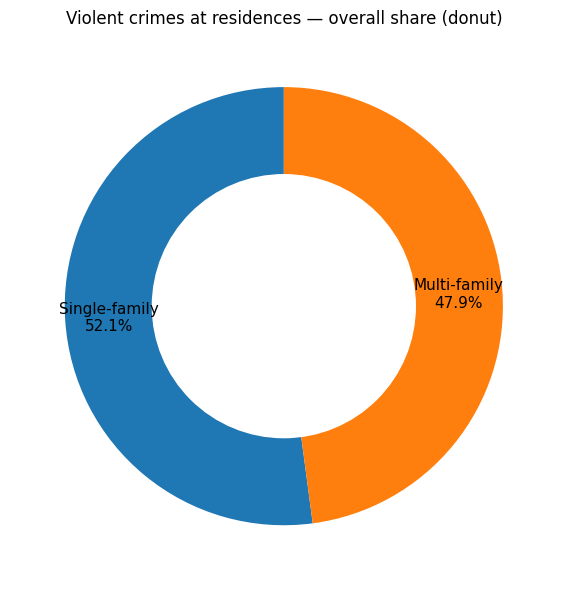

In [44]:
# Keep only violent crimes at residential locations
rv = h3[(h3['CRIME_CLASS']=='VIOLENT') &
        (h3['HOME_TYPE'].isin(['SINGLE_FAMILY','MULTI_FAMILY']))].copy()

#A) Donut chart 
overall = rv['HOME_TYPE'].value_counts().reindex(['SINGLE_FAMILY','MULTI_FAMILY']).fillna(0)
labels = ['Single-family','Multi-family']
sizes = overall.values
total = sizes.sum()

fig, ax = plt.subplots(figsize=(6,6))
wedges, _ = ax.pie(sizes, startangle=90)
centre_circle = plt.Circle((0,0), 0.60, color='white')
ax.add_artist(centre_circle)
ax.set_title('Violent crimes at residences — overall share (donut)')
for i, w in enumerate(wedges):
    ang = (w.theta2 - w.theta1)/2. + w.theta1
    x = np.cos(np.deg2rad(ang))*0.8; y = np.sin(np.deg2rad(ang))*0.8
    pct = 100.0 * sizes[i] / total
    ax.text(x, y, f"{labels[i]}\n{pct:.1f}%", ha='center', va='center', fontsize=11)
plt.tight_layout();
plt.savefig(figures/"Violent crimes at residences overall share (donut).png", dpi=300, bbox_inches="tight") 
plt.show()



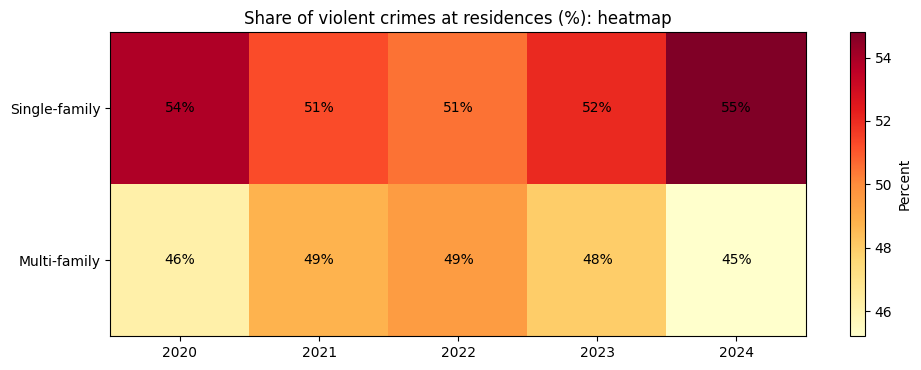

In [45]:
# B) Heatmap 
year_counts = (rv.groupby(['YEAR','HOME_TYPE'])
                 .size()
                 .reset_index(name='COUNT'))
year_totals = year_counts.groupby('YEAR')['COUNT'].transform('sum')
year_counts['SHARE'] = year_counts['COUNT'] / year_totals

heat = (year_counts.pivot(index='HOME_TYPE', columns='YEAR', values='SHARE')
                     .reindex(index=['SINGLE_FAMILY','MULTI_FAMILY'])
                     .fillna(0) * 100)

fig, ax = plt.subplots(figsize=(10,3.8))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(['Single-family','Multi-family'])
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns.astype(int))
ax.set_title('Share of violent crimes at residences (%): heatmap')
cbar = plt.colorbar(im, ax=ax); cbar.set_label('Percent')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i,j]:.0f}%", ha='center', va='center', color='black')
plt.tight_layout(); 
plt.savefig(figures/"Share of violent crimes at residences heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
